In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

from sppaper.kinematics.trajectory import inv_align_traj
from sppaper.kinematics.data import align_smooth_decompose_trajectories

In [3]:
VISUALIZED_SIM_DIR = Path("../../output_data/neuromechfly_replay/kp150_damp0.5_slidfric2.0/snippet21")

In [4]:
with open(VISUALIZED_SIM_DIR / "sim_data.pkl", "rb") as f:
    sim_data = pickle.load(f)

In [5]:
kinematic_snippet = sim_data["snippet"]
sim_results = sim_data["sim_results"]

In [6]:
traj_info = align_smooth_decompose_trajectories(kinematic_snippet, sim_results)
align_info = traj_info["rec_traj_alignment_transform"]

In [7]:
basetraj_rec_unaligned = inv_align_traj(traj_info["basetraj_rec_filtered"], align_info["R"], align_info["t"])

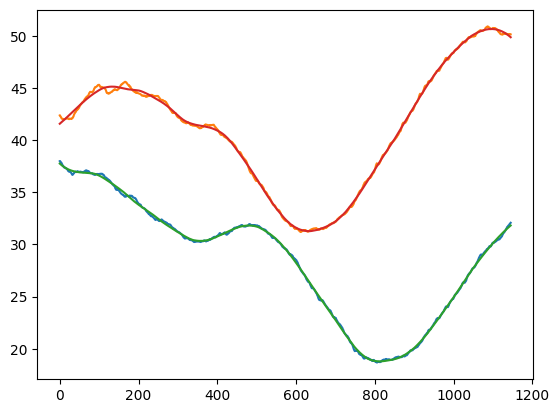

In [8]:
plt.plot(kinematic_snippet.thorax_pos_mm)
plt.plot(basetraj_rec_unaligned)

In [9]:
sim_results["thorax_pos_inputmatched"]

array([[ 0.0000000e+00,  0.0000000e+00],
       [-5.1487982e-03, -1.8180290e-02],
       [-7.0159733e-03, -2.1377334e-02],
       ...,
       [ 1.5465186e+01, -2.2021887e+00],
       [ 1.5440639e+01, -2.2213905e+00],
       [ 1.5383410e+01, -2.2277656e+00]], shape=(1146, 2), dtype=float32)

In [10]:
kinematic_snippet.thorax_pos_px
kinematic_snippet.neck_pos_px

array([[ 811.5599 , 1092.8462 ],
       [ 799.8447 , 1081.8535 ],
       [ 787.7674 , 1079.734  ],
       ...,
       [1079.926  ,  974.4473 ],
       [1079.8203 ,  985.3357 ],
       [1079.2823 ,  986.25433]], shape=(1146, 2), dtype=float32)

In [ ]:
# load 